# Charged Particle Trajectory in a Solved Field

Rebuilt from `legacy/Laplaces Equation for Potential.ipynb`'s demo. That
notebook only solved Laplace's equation (no real charge source, just a
fixed-potential region acting as a boundary condition) and integrated a
test particle with a "swap positions" boundary hack that doesn't
conserve momentum correctly. This version solves *Poisson's* equation
for a real charged conducting disk, and integrates a test charge through
the resulting field with proper leapfrog and a correct elastic-reflection
boundary condition (flip the velocity component into the wall, not swap
positions).

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
from scipy.interpolate import RegularGridInterpolator

import poisson as p

os.makedirs('media', exist_ok=True)

## Solve for the field of a charged disk

A circular conducting disk held at fixed potential `V0=5`, grounded outer
box -- a genuine Poisson solve (the disk is the source of the field, not
just an arbitrary boundary condition).

In [3]:
N = 201
dx = dy = 0.05
Lx = Ly = (N - 1) * dx
x, y = np.arange(N) * dx, np.arange(N) * dy
X, Y = np.meshgrid(x, y, indexing='ij')
cx, cy = Lx / 2, Ly / 2

rho = np.zeros((N, N))
fixed_mask = np.zeros((N, N), dtype=bool)
fixed_values = np.zeros((N, N))
charge_radius = 0.3
disk = ((X - cx)**2 + (Y - cy)**2) <= charge_radius**2
fixed_mask[disk] = True
fixed_values[disk] = 5.0
fixed_mask[0, :] = fixed_mask[-1, :] = fixed_mask[:, 0] = fixed_mask[:, -1] = True  # grounded box

V = p.solve_poisson(rho, dx, dy, fixed_mask, fixed_values)
Ex, Ey = p.efield(V, dx, dy)

Ex_i = RegularGridInterpolator((x, y), Ex, bounds_error=False, fill_value=0.0)
Ey_i = RegularGridInterpolator((x, y), Ey, bounds_error=False, fill_value=0.0)
V_i = RegularGridInterpolator((x, y), V, bounds_error=False, fill_value=0.0)

def accel(pos, q, m):
    return q * np.array([Ex_i(pos)[0], Ey_i(pos)[0]]) / m

## Integrate a test charge (opposite sign, so it's attracted)

Note this is genuinely different from 3D Coulomb orbits: the field here
falls off as `E ~ 1/r` (from the 2D log potential), not `1/r^2`. By
Bertrand's theorem only `1/r^2` and `r` force laws give closed orbits, so
a bound orbit here generically **precesses** (a rosette pattern) rather
than tracing a fixed ellipse -- reported as the actual (and correct)
behavior of this force law, not treated as a bug. The initial speed is
calibrated from the locally-measured field to give a bound, moderately
eccentric orbit that stays well clear of the charged disk.

In [4]:
q, m = -1.0, 1.0
r0 = 2.5
pos0 = np.array([cx + r0, cy])
E0_vec = np.array([Ex_i(pos0)[0], Ey_i(pos0)[0]])
v_circ = np.sqrt(abs(q) * np.linalg.norm(E0_vec) * r0 / m)
vel0 = np.array([0.0, 0.85 * v_circ])  # slightly sub-circular -> visibly eccentric, precessing orbit
print(f'circular-orbit speed estimate at r0={r0}: {v_circ:.4f}; using {0.85*v_circ:.4f}')

dt = 0.001
n_steps = 40000
pos, vel = pos0.copy(), vel0.copy()
traj = np.zeros((n_steps + 1, 2))
energy = np.zeros(n_steps + 1)
traj[0] = pos
energy[0] = 0.5 * m * np.sum(vel**2) + q * V_i(pos)[0]

for i in range(1, n_steps + 1):
    a = accel(pos, q, m)
    vel_half = vel + 0.5 * dt * a
    pos_new = pos + dt * vel_half
    for d in (0, 1):  # elastic reflection off the box walls
        if pos_new[d] < 0:
            pos_new[d] = -pos_new[d]
            vel_half[d] = -vel_half[d]
        elif pos_new[d] > Lx:
            pos_new[d] = 2 * Lx - pos_new[d]
            vel_half[d] = -vel_half[d]
    a_new = accel(pos_new, q, m)
    vel_new = vel_half + 0.5 * dt * a_new
    pos, vel = pos_new, vel_new
    traj[i] = pos
    energy[i] = 0.5 * m * np.sum(vel**2) + q * V_i(pos)[0]

circular-orbit speed estimate at r0=2.5: 1.3105; using 1.1140


energy relative drift over 40000 steps: 5.86e-04
orbit radius range: 1.878 to 2.506 (charged disk radius: 0.3)
PASS: energy conserved and the orbit stays a safe distance from the charged disk.


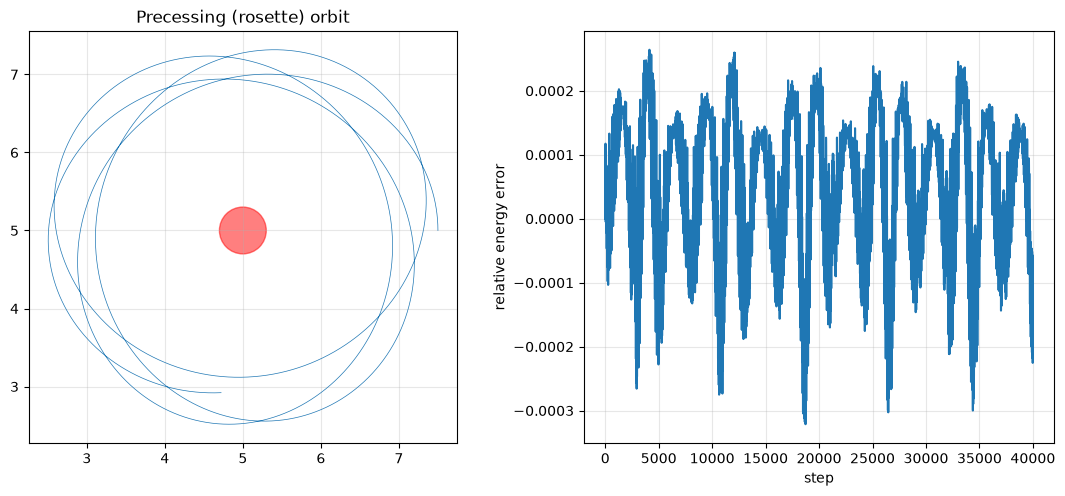

In [5]:
r_traj = np.linalg.norm(traj - [cx, cy], axis=1)
E_drift = (energy.max() - energy.min()) / abs(energy.mean())
print(f'energy relative drift over {n_steps} steps: {E_drift:.2e}')
print(f'orbit radius range: {r_traj.min():.3f} to {r_traj.max():.3f} (charged disk radius: {charge_radius})')
assert E_drift < 0.01, 'energy drift too large -- trajectory integration is not trustworthy'
assert r_traj.min() > charge_radius, 'test charge crossed into the charged disk -- integration or setup issue'
print('PASS: energy conserved and the orbit stays a safe distance from the charged disk.')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(traj[:, 0], traj[:, 1], lw=0.5)
axes[0].add_patch(plt.Circle((cx, cy), charge_radius, color='r', alpha=0.5))
axes[0].set_aspect('equal'); axes[0].set_title('Precessing (rosette) orbit'); axes[0].grid(alpha=0.3)
axes[1].plot((energy - energy[0]) / abs(energy[0]))
axes[1].set_xlabel('step'); axes[1].set_ylabel('relative energy error'); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/particle_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [6]:
frame_stride = 40
frames = traj[::frame_stride]

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('k')
ax.set(xlim=(0, Lx), ylim=(0, Ly))
ax.set_xticks([]); ax.set_yticks([])
ax.add_patch(plt.Circle((cx, cy), charge_radius, color='red', alpha=0.6))
trail, = ax.plot([], [], '-', color='cyan', alpha=0.5, linewidth=0.8)
dot, = ax.plot([], [], 'o', color='white', markersize=6)
trail_x, trail_y = [], []

def animate(i):
    dot.set_data([frames[i, 0]], [frames[i, 1]])
    trail_x.append(frames[i, 0]); trail_y.append(frames[i, 1])
    trail.set_data(trail_x[-400:], trail_y[-400:])
    return dot, trail

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=25, blit=True)
ani.save('media/particle_trajectory.mp4', writer='ffmpeg', fps=40, dpi=130)
plt.close(fig)
print('saved media/particle_trajectory.mp4')

saved media/particle_trajectory.mp4


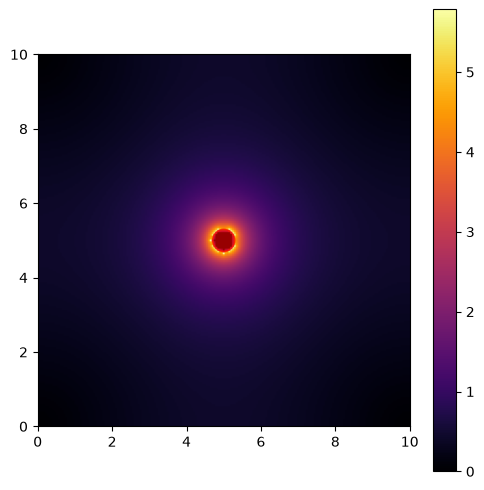

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('k')
ax.set(xlim=(0, Lx), ylim=(0, Ly))
ax.add_patch(plt.Circle((cx, cy), charge_radius, color='red', alpha=0.6))
E_mag = np.sqrt(Ex**2 + Ey**2)
im = ax.imshow(E_mag.T, extent=(0, Lx, 0, Ly), origin='lower', cmap='inferno', vmin=0, vmax=E_mag.max())
cbar = fig.colorbar(im, ax=ax)
ax.set_title('Electric field magnitude')
fig.tight_layout()
fig.savefig('media/field_magnitude.png', dpi=150, bbox_inches='tight')